# DR CVRIE — Supervised Learning : Image dataset Clustering

## References

- **Dataset**: Glaucoma Datasets from Kaggle. Available at: https://www.kaggle.com/datasets/arnavjain1/glaucoma-datasets
- **Libraries**:

  - Pandas: https://pandas.pydata.org/
  - NumPy: https://numpy.org/
  - Matplotlib: https://matplotlib.org/
  - Scikit-learn: https://scikit-learn.org/

- **Methods**:
  - Image preprocessing and resizing based on standard computer vision practices.
  - Oversampling using Scikit-learn's resample function, as described in the Scikit-learn documentation.
  
- **Additional Resources**:
  - For supervised learning concepts: "Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow" by Aurélien Géron.
  - Glaucoma detection research: Refer to medical imaging papers on PubMed or IEEE Xplore.

## Importation of the dataset

### 1. 1 Imports

#### We need to imports all the neceesaary libraries for this part of the project. 

- **pandas / numpy** : data manipulation and numerical operations.
- **Scikit-learn** : Machine learning and processing tools.
- **matplotlib** : Showing graphic image.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
import os


### 1. 2 Loading the Dataset

<!-- We load the dataset using Image.open(), this is a function from the PIL (Pillow) library that opens and identifies the given image file. It returns an Image object that can be used for further processing or display and plt.imshow is a function from the Matplotlib library that displays an image on a 2D regular raster. It takes an array-like object (such as an Image object) and renders it as an image in the current figure.
plt.imshow(img)

> Note: To display the image without the axes, you can use the `plt.axis('off')` function before calling `plt.show()`. This will hide the axes and display only the image. Hiding the axes is necessary for better image visualization, especially if the axes are not relevant to the image's analysis or presentation. The relevance of the axes depends on the image's context and the display's purpose. If the axes do not provide useful information or if the image is intended for aesthetic presentation, it is best to hide them to avoid visual distractions. -->

In [15]:
#load the dataset

df = pd.read_csv('G1020/G1020.csv')

In [16]:
# Verification of the dataset

print(df['binaryLabels'].value_counts())

binaryLabels
0    724
1    296
Name: count, dtype: int64


### 1. 3 Verification and Visualization of the Dataset

#### We verify the dataset by checking the class distribution and visualize it with a bar plot to understand the imbalance between normal and glaucoma images.

- **value_counts()** : Counts occurrences of each class in 'binaryLabels'.
- **plot(kind='bar')** : Creates a bar chart for visualization.
- **plt.xticks()** : Customizes x-axis labels for clarity.

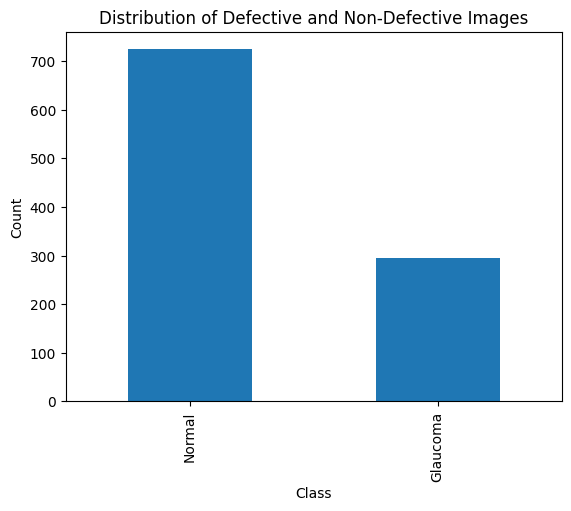

In [17]:
#visualisation of defective and non-defective images
#this line is used for visualisation of the distribution of the defective and non defective images in the dataset
(df['binaryLabels'].value_counts()).plot(kind='bar')

#this line is used to set the title, x and y labels of the plot and to show the plot
plt.title('Distribution of Defective and Non-Defective Images')

#this line is used to set the x and y ticks of the plot and to show the plot and to set the x and y labels of the plot
plt.xticks([0, 1], ['Normal', 'Glaucoma'])
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


### 1. 4 Image Loading and Preprocessing

#### We define a function to load images from the dataset, resize them to a standard size, and normalize pixel values for model input. This preprocessing ensures consistency and improves model convergence.

- **load_images()** : Custom function that takes a DataFrame, image folder path, and target size. It iterates over rows, constructs full paths, loads images using PIL, resizes them, and collects into arrays.

- **Normalization** : Divides pixel values by 255.0 to scale from [0,255] to [0,1], which is standard for neural networks and prevents large gradients.

- **Flattening** : Reshapes 3D arrays (height, width, channels) to 2D (samples, features) for compatibility with Scikit-learn models like SVM or logistic regression.

- **Error Handling** : Uses try-except to skip missing images and print warnings, ensuring robustness.

- **Return Values** : Returns NumPy arrays for images (x) and labels (y), ready for training.

In [18]:
def load_images(df, image_folder, target_size=(224, 224)):
    images = []
    labels = []

    for index, row in df.iterrows():
        image_path = f"{image_folder}/{row['imageID']}"
        try:
            image = mpimg.imread(image_path)
            images.append(image)
            labels.append(row['binaryLabels'])
        except FileNotFoundError:
            print(f"Image not found: {image_path}")
        
    return np.array(images), np.array(labels)


### 1. 5 Image Verification and Flattening

#### After loading and normalizing images, we display a sample image to verify correctness and flatten the data for machine learning models. This step confirms data integrity and prepares it for algorithms requiring 2D input.

- **plt.imshow()** : Displays the first image array using matplotlib, showing RGB channels.

- **plt.title()** : Adds a title with the label (e.g., "Label: 0" or "Label: 1") for verification.

- **plt.axis('off')** : Hides axes for cleaner visualization.

- **x.reshape()** : Flattens each 3D image into a 1D vector, resulting in a 2D array where rows are samples and columns are features (e.g., 224*224*3 = 150528 features).

- **print()** : Outputs the shape of the flattened array to confirm dimensions.

In [ ]:
#Normalization of the images

x, y = load_images(df, 'G1020/Images_Square')
x = x / 255.0

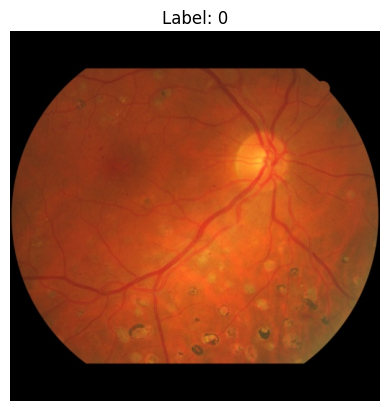

In [ ]:
# Display the first image and its label to verify that the images are loaded correctly
plt.imshow(x[0])
plt.title(f"Label: {y[0]}")
plt.axis('off')
plt.show()

In [ ]:
#Applatissement des images pour les modèles de machine learning
#scikit-learn models require 2D input, so we need to flatten the images from 3D (height, width, channels) to 2D (samples, features)
x_flattened = x.reshape(x.shape[0], -1)

#128x128x3 = 49152 features per image, so the new shape of x_flattened will be (number of samples, 49152)
print(x_flattened.shape)


(1020, 786432)


### 1. 6 Dataset Balancing

#### The dataset is imbalanced, so we oversample the minority class to balance it for better model training. Imbalanced data can lead to biased models that perform poorly on minority classes.

- **resample()** : Oversamples the minority class with replacement, matching the majority class size. Uses random_state for reproducibility.

- **pd.concat()** : Combines the original majority DataFrame with the upsampled minority DataFrame into a new balanced DataFrame.

- **value_counts()** : Verifies the balanced distribution by printing counts, ensuring equal representation of classes.

- **df_majority and df_minority** : Split the original DataFrame by label to isolate classes for resampling.

In [ ]:
# Disorder gestion of the dataset
# The dataset is imbalanced, so we need to balance it before training the model. We can use the resample function from sklearn to balance the dataset by oversampling the minority class or undersampling the majority class. In this case, we will oversample the minority class (defective images
# We will use the resample function to oversample the minority class (defective images) to balance the dataset
# We will create a new dataframe with the balanced dataset and then we will use this new dataframe to train the model. We will use the value_counts() function to check the distribution of the classes in the balanced dataset.
df_majority =df[df['binaryLabels'] == 0]
df_minority = df[df['binaryLabels'] == 1]

In [ ]:
# Oversample the minority class by resampling with replacement
df_minority_upsampled = resample(df_minority, replace=True, n_samples=len(df_majority), random_state=42)

In [ ]:
# Combine the majority class with the upsampled minority class to create a new balanced dataframe
# We will use the value_counts() function to check the distribution of the classes in the balanced dataset.
df_balanced = pd.concat([df_majority, df_minority_upsampled])

In [ ]:
print(df_balanced['binaryLabels'].value_counts())

binaryLabels
0    724
1    724
Name: count, dtype: int64


### 1. 7 Data-preprocessing

In [ ]:
from sklearn.model_selection import train_test_split

print("Dataset columns:", df.columns)
print("Dataset shape:", df.shape)

target_column = "target"

if target_column not in df.columns:
    raise ValueError(f"Target column '{target_column}' not found.")

X = df.drop(columns=[target_column])
y = df[target_column]

X = X.select_dtypes(include=['number'])

if X.shape[1] == 0:
    raise ValueError("No numeric columns found in X.")

print("Shape of X after cleaning:", X.shape)

X = X.fillna(X.mean())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

ValueError: at least one array or dtype is required

### 1. 8 Model Comparison & Training

 #### Model A: Random Forest (Ensemble Learning)

  - **Loss Function**: Gini Impurity or Entropy.

  - **Explanation**: It measures how often a randomly chosen element from the set would be incorrectly labeled. Minimizing this "loss" ensures the nodes in the tree are as "pure" as possible.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Results:\n", classification_report(y_test, rf_pred))